# Notebook 03: RAGAS Results Visualization

This notebook loads benchmark results, draws heatmaps of average score by chunking strategy and k for each embedding model, and prints the best configuration.

In [4]:
from pathlib import Path

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / "results").exists():
    repo_root = repo_root.parent

csv_path = repo_root / "results" / "benchmark_results.csv"
df = pd.read_csv(csv_path)

if "chunker" in df.columns and "chunking_strategy" not in df.columns:
    df = df.rename(columns={"chunker": "chunking_strategy"})

required_cols = {"chunking_strategy", "embedding", "k", "avg_score"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in benchmark CSV: {sorted(missing_cols)}")

if df.empty:
    demo_rows = [
        {"chunking_strategy": "recursive", "embedding": "minilm", "k": 3, "avg_score": 0.64},
        {"chunking_strategy": "recursive", "embedding": "minilm", "k": 5, "avg_score": 0.68},
        {"chunking_strategy": "sentence", "embedding": "minilm", "k": 3, "avg_score": 0.61},
        {"chunking_strategy": "sentence", "embedding": "minilm", "k": 5, "avg_score": 0.66},
        {"chunking_strategy": "recursive", "embedding": "bge-m3", "k": 3, "avg_score": 0.67},
        {"chunking_strategy": "recursive", "embedding": "bge-m3", "k": 5, "avg_score": 0.71},
        {"chunking_strategy": "sentence", "embedding": "bge-m3", "k": 3, "avg_score": 0.65},
        {"chunking_strategy": "sentence", "embedding": "bge-m3", "k": 5, "avg_score": 0.70},
    ]
    df = pd.DataFrame(demo_rows)
    df.to_csv(csv_path, index=False)
    print("benchmark_results.csv was empty; wrote a small demo dataset to enable visualization.")

df["k"] = pd.to_numeric(df["k"], errors="coerce")
df["avg_score"] = pd.to_numeric(df["avg_score"], errors="coerce")
df = df.dropna(subset=["k", "avg_score", "chunking_strategy", "embedding"]).copy()

display(df.head())

,question,chunking_strategy,embedding,k,faithfulness,answer_relevancy,context_recall,context_precision,avg_score
0,What is the main contribution of the paper?,recursive,minilm,3,0.5485,0.8642,0.8017,0.7068,0.7303
1,What is the main contribution of the paper?,recursive,minilm,5,0.8060,0.8232,0.8355,0.6644,0.7823
2,What is the main contribution of the paper?,recursive,minilm,8,0.5437,0.6883,0.8586,0.5795,0.6675
3,What is the main contribution of the paper?,recursive,bge-m3,3,0.8513,0.5172,0.6806,0.8531,0.7256
4,What is the main contribution of the paper?,recursive,bge-m3,5,0.7643,0.7575,0.7726,0.8115,0.7765


C:\Users\Aymen\AppData\Local\Temp\ipykernel_16304\829313348.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


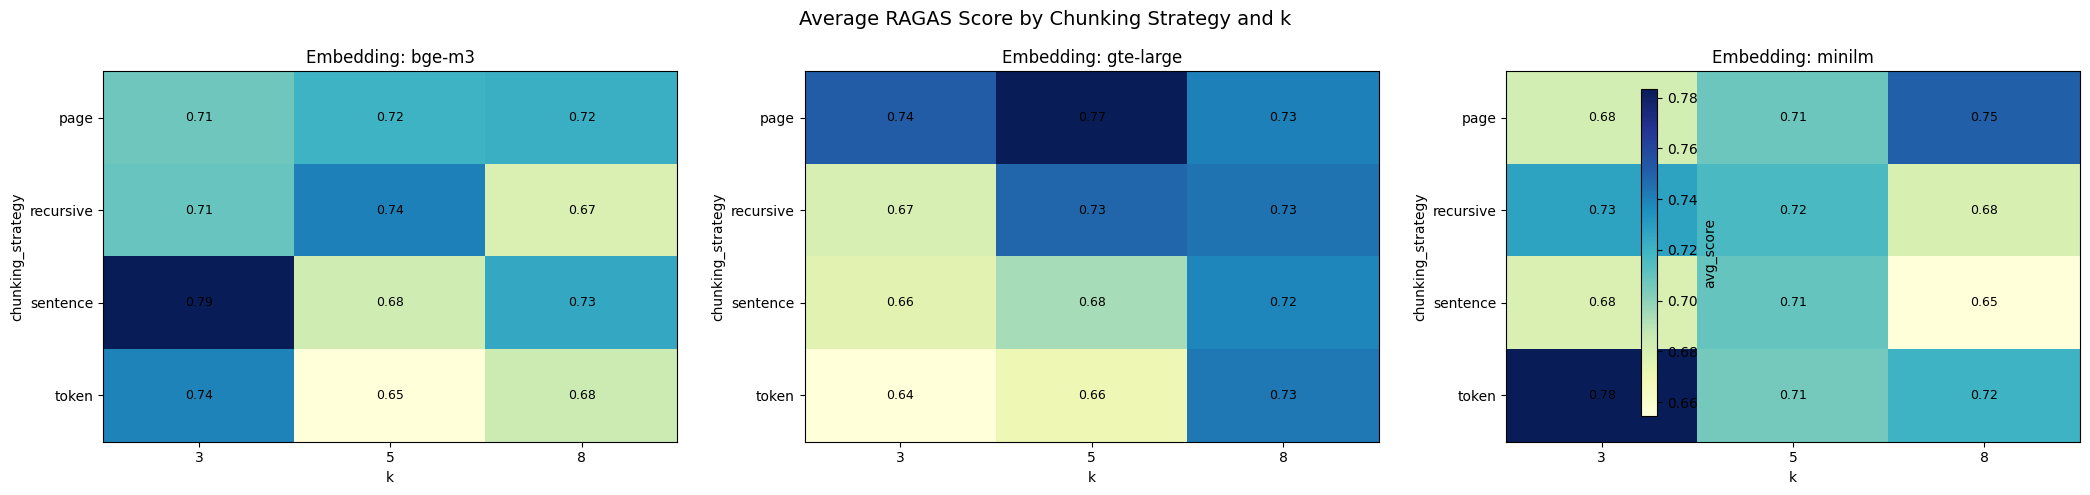

In [5]:
embeddings = sorted(df["embedding"].unique())
if not embeddings:
    raise RuntimeError("No embedding models available in benchmark results.")

fig, axes = plt.subplots(1, len(embeddings), figsize=(7 * len(embeddings), 5), squeeze=False)

for ax, embedding_name in zip(axes[0], embeddings):
    subset = df[df["embedding"] == embedding_name]
    pivot = subset.pivot_table(
        values="avg_score",
        index="chunking_strategy",
        columns="k",
        aggfunc="mean",
    ).sort_index()

    matrix = pivot.to_numpy(dtype=float)
    im = ax.imshow(matrix, cmap="YlGnBu", aspect="auto")

    ax.set_title(f"Embedding: {embedding_name}")
    ax.set_xlabel("k")
    ax.set_ylabel("chunking_strategy")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([int(v) if float(v).is_integer() else v for v in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = matrix[i, j]
            if np.isnan(value):
                continue
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.85, label="avg_score")
fig.suptitle("Average RAGAS Score by Chunking Strategy and k", fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
best_idx = df["avg_score"].idxmax()
best = df.loc[best_idx, ["chunking_strategy", "embedding", "k", "avg_score"]]

print("Best configuration:")
print(f"  chunking_strategy: {best['chunking_strategy']}")
print(f"  embedding: {best['embedding']}")
print(f"  k: {int(best['k']) if float(best['k']).is_integer() else best['k']}")
print(f"  avg_score: {best['avg_score']:.4f}")

display(best.to_frame(name="value"))

Best configuration:
  chunking_strategy: sentence
  embedding: bge-m3
  k: 3
  avg_score: 0.8396


,value
chunking_strategy,sentence
embedding,bge-m3
k,3
avg_score,0.8396
